In [2]:
# Importing moblienetV2 and necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import (MobileNetV2, preprocess_input)
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import json


In [3]:
#Defining the path of the image and loading it
train_dir="plant_dataset/train"
val_dir="plant_dataset/val"
test_dir="plant_dataset/test"
SEED = 42
tf.random.set_seed(SEED)

In [4]:
#Loading datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=True, seed=SEED)
val_ds = image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False)
test_ds = image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=False)

Found 7680 files belonging to 80 classes.
Found 960 files belonging to 80 classes.
Found 960 files belonging to 80 classes.


In [5]:
#Checking class names
class_names = train_ds.class_names
print(class_names)
print(f"Number of classes: {len(class_names)}")

['Aloevera', 'Amruthaballi', 'Arali', 'Badipala', 'Bamboo', 'Banmaso', 'Beans', 'Betel', 'Bethee', 'Bhojo', 'Bhrami', 'Bringaraja', 'Castor', 'Catharanthus', 'Chakte', 'Chameli', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Gaja', 'Ganigale', 'Ganike', 'Gasagase', 'Ginger', 'Globe Amarnath', 'Guva', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kagati', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Neem', 'Nelavembu', 'Nerale', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Parijatha', 'Pati', 'Pea', 'Pomoegranate', 'Pudina', 'Pumpkin', 'Raddish', 'Rose', 'Sampige', 'Sapota', 'Seethaashoka', 'Seethapala', 'Spinach1', 'Tamarind', 'Taro', 'Tecoma', 'Thumbe', 'Tomato', 'Tulsi', 'Turmeric', 'ashoka', 'camphor', 'kamakasturi', 'kepala']
Number of classes: 80


In [6]:
#Agumenting the data
data_augmentation = tf.keras.Sequential([
      tf.keras.layers.RandomFlip("horizontal"),        
    tf.keras.layers.RandomRotation(0.08),            
    tf.keras.layers.RandomZoom(0.1),                 
    tf.keras.layers.RandomTranslation(0.08, 0.08),  
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [7]:
#Preprocessing for MobileNetV2
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))      
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))      

In [8]:
#Optimizing the model for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
val_ds = val_ds.cache()
test_ds = test_ds.cache()
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [9]:
#Imorting the MobileNetV2 model and training it on our dataset
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False #Freeze the base model layers for transfer learning

#Adding custom layers for our specific classification task
num_classes = len(class_names)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x) #Adding dropout for regularization
x=Dense(256, activation='relu')(x)
x=Dropout(0.3)(x)
predictions=Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

#Compiling the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Callback for early stopping
checkpoint=ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stopping=EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

Training the model

In [10]:
#Training the model
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, early_stopping]
)

end_time = time.time()

total_time = end_time - start_time

print(f"\nTotal training time: {total_time:.2f} seconds")
print(f"Total training time: {total_time/60:.2f} minutes")


Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0888 - loss: 4.1282
Epoch 1: val_accuracy improved from -inf to 0.53125, saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/step - accuracy: 0.0892 - loss: 4.1258 - val_accuracy: 0.5312 - val_loss: 2.0392
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3812 - loss: 2.3442
Epoch 2: val_accuracy improved from 0.53125 to 0.65104, saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.3813 - loss: 2.3435 - val_accuracy: 0.6510 - val_loss: 1.3964
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5101 - loss: 1.7843
Epoch 3: val_accuracy improved from 0.65104 to 0.67917, saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.5101 - loss: 1.7841 - val_accuracy: 0.6792 - val_loss: 1.1698
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.5718 - loss: 1.4978
Epoch 4: val_accuracy improved from 0.6

 Fine Tuning

In [11]:
# Unfreeze the base model layers for fine-tuning (only top 40 layers)
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

#Recompile the model with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy'])

 #Add callbacks for safety and performance
checkpoint_finetune=tf.keras.callbacks.ModelCheckpoint(
    'best_model_finetune.keras',
     monitor='val_accuracy', 
     save_best_only=True, 
      verbose=1)

early_stop_finetune=tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True)

start_time = time.time()

#Fine-tune for a few epochs
history_finetune=model.fit(train_ds,
 validation_data=val_ds,
 epochs=15,
 callbacks=[checkpoint_finetune, early_stop_finetune])

end_time = time.time()
total_time_finetune = end_time - start_time
print(f"\nTotal fine-tuning time: {total_time_finetune:.2f} seconds")
print(f"Total fine-tuning time: {total_time_finetune/60:.2f} minutes")


Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7814 - loss: 0.7234
Epoch 1: val_accuracy improved from -inf to 0.84583, saving model to best_model_finetune.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.7814 - loss: 0.7232 - val_accuracy: 0.8458 - val_loss: 0.5071
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8048 - loss: 0.6184
Epoch 2: val_accuracy improved from 0.84583 to 0.85417, saving model to best_model_finetune.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.8048 - loss: 0.6184 - val_accuracy: 0.8542 - val_loss: 0.4804
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8146 - loss: 0.5926
Epoch 3: val_accuracy improved from 0.85417 to 0.85729, saving model to best_model_finetune.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.8146 - loss: 0.5926 - val_accuracy: 0.8573 - val_loss: 0.4499
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8301 - loss: 0.5527
Epoch 4: val_ac

Saving the model

In [3]:
model.save('final_mobilenet_model.keras')

NameError: name 'model' is not defined

In [13]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 850ms/step - accuracy: 0.8912 - loss: 0.3123
Validation Accuracy: 0.8917
Validation Loss: 0.3283


Prediction on test dataset

In [2]:
#Prediction on test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


NameError: name 'model' is not defined

Summary of model

In [15]:
#Getting predictions and true labels for confusion matrix
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
#Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 809ms/step
Classification Report:
                         precision    recall  f1-score   support

               Aloevera       0.92      1.00      0.96        12
           Amruthaballi       1.00      1.00      1.00        12
                  Arali       1.00      1.00      1.00        12
               Badipala       0.91      0.83      0.87        12
                 Bamboo       0.86      1.00      0.92        12
                Banmaso       1.00      0.83      0.91        12
                  Beans       0.79      0.92      0.85        12
                  Betel       1.00      1.00      1.00        12
                 Bethee       0.75      1.00      0.86        12
                  Bhojo       1.00      0.92      0.96        12
                 Bhrami       1.00      0.83      0.91        12
             Bringaraja       0.69      0.92      0.79        12
                 Castor       0.83      0.83      0.83        12
           Catharanthus 

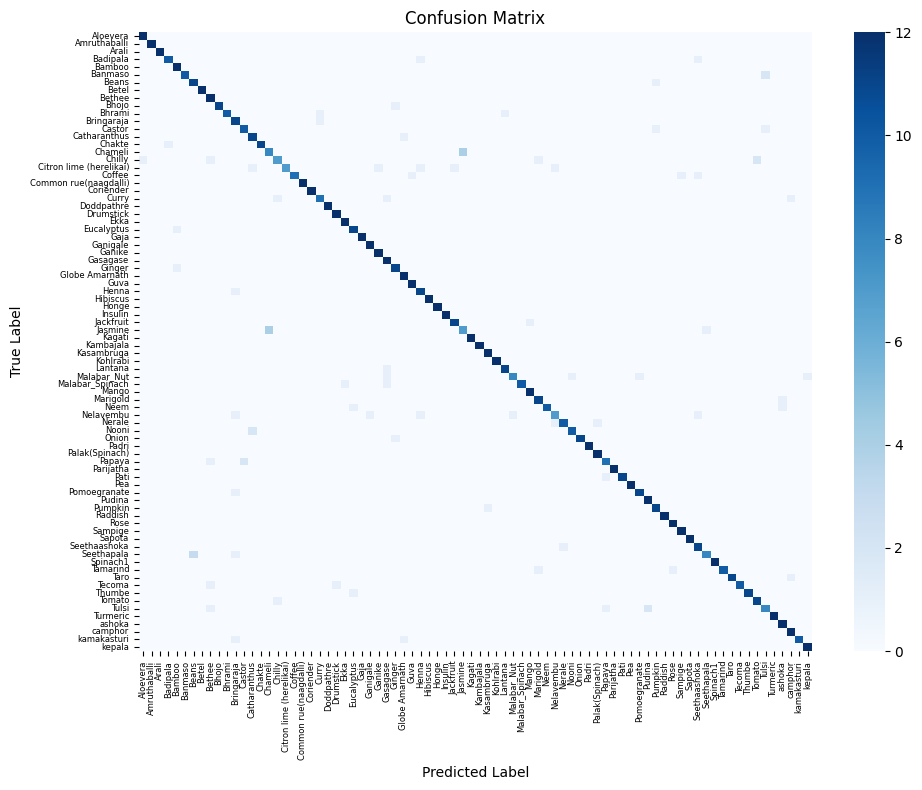

In [24]:
#plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

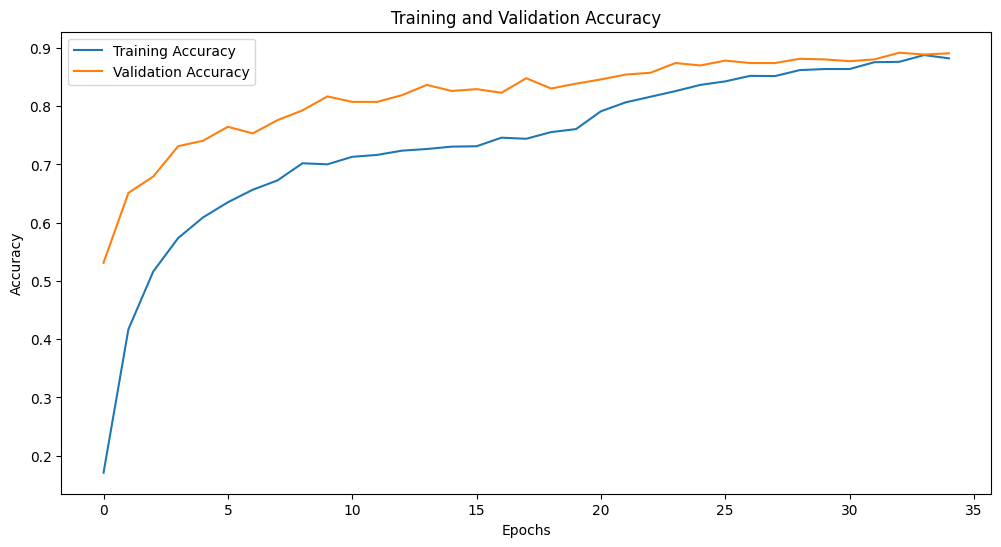

In [18]:
#plotting the training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


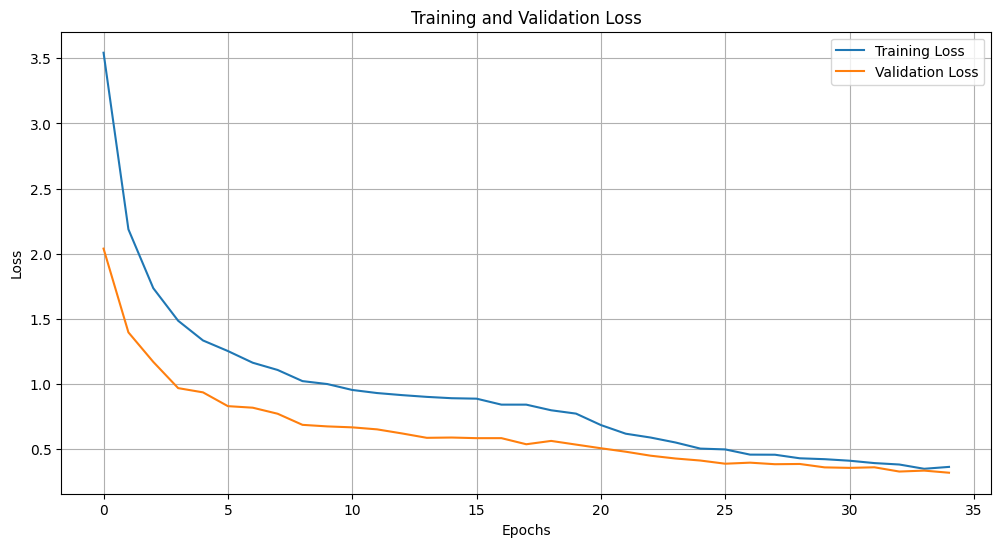

In [20]:
#plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'] + history_finetune.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'] + history_finetune.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


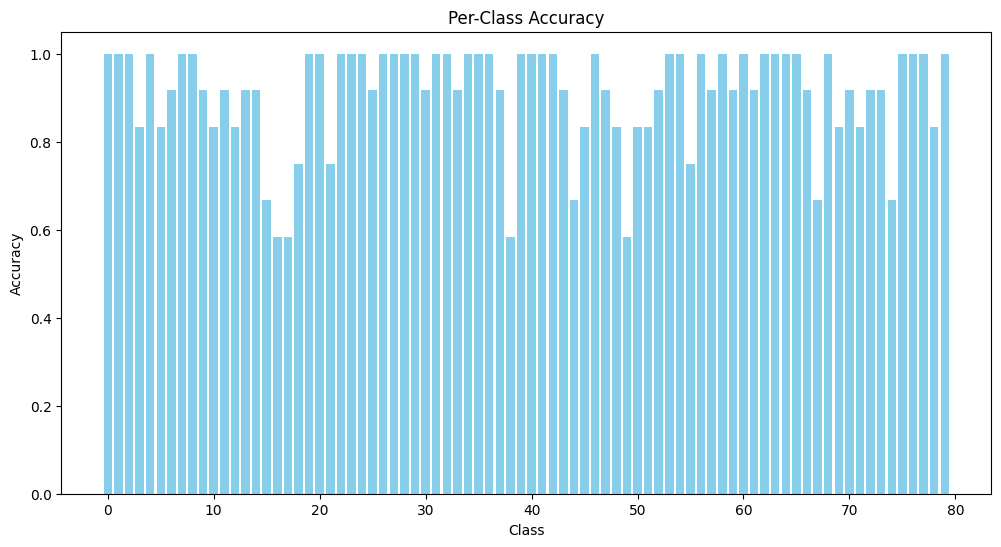

In [21]:
#plotting the per-class accuracy
class_correct= np.zeros(len(class_names))
class_total = np.zeros(len(class_names))

for true, pred in zip(y_true, y_pred):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

class_accuracy = class_correct / class_total
plt.figure(figsize=(12, 6))
plt.bar(range(len(class_names)), class_accuracy, color='skyblue')
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

Prediction on real image

In [6]:
#Example: Single image prediction 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
IMG_SIZE = (224, 224)


# Load image
img_path="leaf.jpg"
image = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=IMG_SIZE
)

# Convert to array
input_arr = tf.keras.preprocessing.image.img_to_array(image)

# Add batch dimension
input_arr = np.expand_dims(input_arr, axis=0)

# IMPORTANT: preprocess correctly
input_arr = tf.keras.applications.mobilenet_v2.preprocess_input(input_arr)

# Load model (DO THIS ONCE, not every prediction ideally)
model = tf.keras.models.load_model('final_mobilenet_model.keras')

# Predict
predictions = model.predict(input_arr)

# Get class
predicted_class = np.argmax(predictions, axis=1)[0]
predicted_label = class_names[predicted_class]

# Confidence
confidence = np.max(predictions)
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.4f}")

result = {
    "predicted_class": predicted_label,
    "confidence": float(confidence*100)
}

# Show the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(
    f"Final Prediction: {result['predicted_class']}\n"
    f"Confidence: {result['confidence']:.4f}"
)
plt.axis('off')
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


NameError: name 'class_names' is not defined

In [ ]:
model.summary()

In [43]:
#prediction index into json
import json
with open('class_indices.json', 'w') as f:
    json.dump({idx: name for idx, name in enumerate(class_names)}, f, indent=2)